In [1]:
 import tensorflow as tf
 import numpy as np
 from sklearn.datasets import fetch_lfw_people
 from sklearn.model_selection import train_test_split
 from tensorflow.keras.applications.vgg16 import VGG16, preprocess_input
 from tensorflow.keras.utils import to_categorical
 import cv2
 import matplotlib.pyplot as plt

In [2]:
 # Load LFW dataset with minimum 20 images per person
 lfw_people = fetch_lfw_people(min_faces_per_person=20, resize=0.5)
 images = lfw_people.images
 labels = lfw_people.target
 label_names = lfw_people.target_names
 num_classes = len(label_names)

 print("Total samples:", images.shape[0])
 print("Image shape:", images.shape[1:])
 print("Number of classes:", num_classes)

Total samples: 3023
Image shape: (62, 47)
Number of classes: 62


In [3]:
 # Resize images to 224x224 RGB for VGG16
 resized_images = np.zeros((images.shape[0], 224, 224, 3), dtype='float32')

 for i in range(images.shape[0]):
  img = cv2.cvtColor(images[i], cv2.COLOR_GRAY2RGB)
  resized_images[i] = cv2.resize(img, (224, 224))

In [4]:
 # Normalize with VGG16 preprocessing
 resized_images = preprocess_input(resized_images)

In [5]:
 # Load pre-trained VGG16 (excluding top layer)
 vgg_model = VGG16(weights='imagenet', include_top=False, input_shape=(224, 224, 3))

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [6]:
 # Extract features from images
 features = vgg_model.predict(resized_images, verbose=1)
 features = features.reshape(features.shape[0], -1)  # Flatten features

95/95 ━━━━━━━━━━━━━━━━━━━━ 1775s 19s/step


In [7]:
 # One-hot encode labels
 labels_cat = to_categorical(labels, num_classes)

In [8]:
 # Train-test split
 X_train, X_test, y_train, y_test = train_test_split(features, labels_cat, test_size=0.2, random_state=42)
 model = tf.keras.models.Sequential([
 tf.keras.layers.Dense(512, activation='relu', input_shape=(features.shape[1],)),
 tf.keras.layers.Dropout(0.5),
 tf.keras.layers.Dense(num_classes, activation='softmax')
 ])
 model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
 model.summary()

/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 512)            │    12,845,568 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 62)             │        31,806 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,877,374 (49.12 MB)

 Trainable params: 12,877,374 (49.12 MB)

 Non-trainable params: 0 (0.00 B)

In [9]:
 history = model.fit(
 X_train, y_train,
 epochs=10,
 batch_size=32,
 validation_split=0.2
 )

Epoch 1/10
61/61 ━━━━━━━━━━━━━━━━━━━━ 19s 277ms/step - accuracy: 0.0900 - loss: 5.6400 - val_accuracy: 0.1880 - val_loss: 3.8637
Epoch 2/10
61/61 ━━━━━━━━━━━━━━━━━━━━ 16s 257ms/step - accuracy: 0.1366 - loss: 3.9871 - val_accuracy: 0.1880 - val_loss: 3.7502
Epoch 3/10
61/61 ━━━━━━━━━━━━━━━━━━━━ 22s 280ms/step - accuracy: 0.1657 - loss: 3.9308 - val_accuracy: 0.1880 - val_loss: 3.7495
Epoch 4/10
61/61 ━━━━━━━━━━━━━━━━━━━━ 19s 262ms/step - accuracy: 0.1670 - loss: 3.8605 - val_accuracy: 0.1880 - val_loss: 3.8218
Epoch 5/10
61/61 ━━━━━━━━━━━━━━━━━━━━ 21s 265ms/step - accuracy: 0.1830 - loss: 3.8945 - val_accuracy: 0.1880 - val_loss: 3.8377
Epoch 6/10
61/61 ━━━━━━━━━━━━━━━━━━━━ 20s 262ms/step - accuracy: 0.1709 - loss: 3.8682 - val_accuracy: 0.1880 - val_loss: 3.7714
Epoch 7/10
61/61 ━━━━━━━━━━━━━━━━━━━━ 21s 266ms/step - accuracy: 0.1765 - loss: 3.8911 - val_accuracy: 0.1880 - val_loss: 3.7613
Epoch 8/10
61/61 ━━━━━━━━━━━━━━━━━━━━ 22s 293ms/step - accuracy: 0.1845 - loss: 3.8219 - val_accu

In [10]:
 loss, accuracy = model.evaluate(X_test, y_test)
 print("✅Test Accuracy:", accuracy)

19/19 ━━━━━━━━━━━━━━━━━━━━ 1s 49ms/step - accuracy: 0.1586 - loss: 3.8238
✅Test Accuracy: 0.16033057868480682


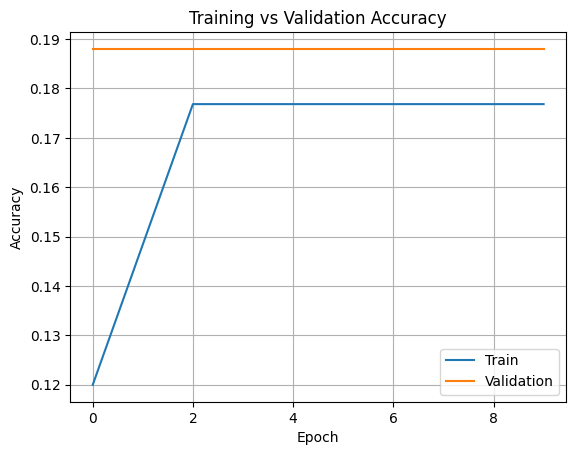

In [11]:
 plt.plot(history.history['accuracy'], label='Train')
 plt.plot(history.history['val_accuracy'], label='Validation')
 plt.xlabel("Epoch")
 plt.ylabel("Accuracy")
 plt.title("Training vs Validation Accuracy")
 plt.legend()
 plt.grid(True)
 plt.show()